In [1]:
import pickle


In [2]:
# load .pkl file
with open("../mario_1_2_expert.pkl", "rb") as f:
    data = pickle.load(f)


Data is a list of dictionaries.

Each dictionary contains dict_keys(['obs', 'action'])

In [3]:
data[0]['obs'].shape

(240, 256, 3)

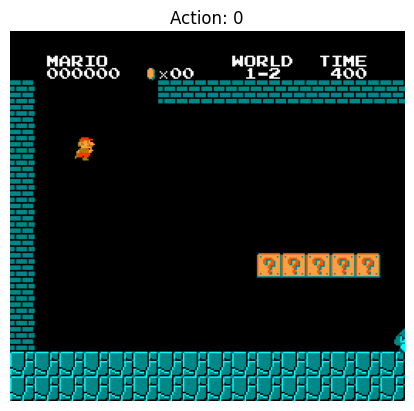

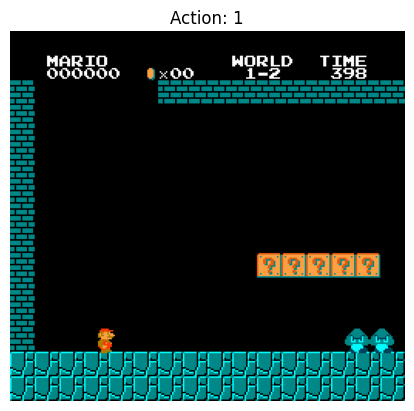

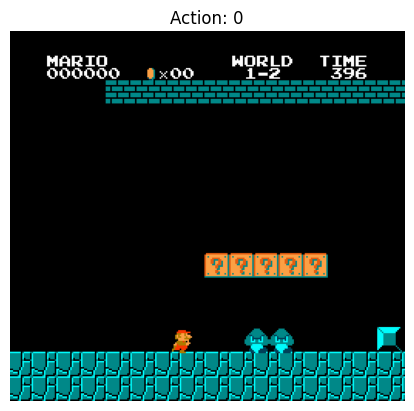

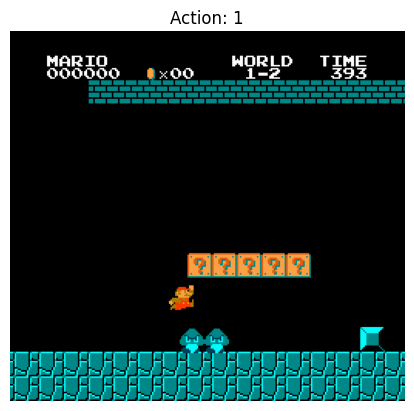

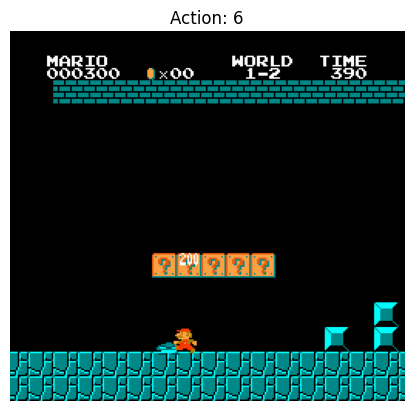

In [4]:
# plot some observations
import matplotlib.pyplot as plt
for i in range(5):
    plt.imshow(data[i*50]['obs'])
    plt.title(f"Action: {data[i*50]['action']}")
    plt.axis('off')
    plt.show()

In [5]:
# Check if observations are actually different
import numpy as np

# Compare first 100 observations
obs_list = [data[i]['obs'] for i in range(min(100, len(data)))]

# Check if all observations are identical
all_same = all(np.array_equal(obs_list[0], obs) for obs in obs_list[1:])
print(f"All observations identical: {all_same}")

# Check diversity: compute pairwise differences
if not all_same:
    # Sample 10 random pairs
    import random
    diffs = []
    for _ in range(10):
        i, j = random.sample(range(len(obs_list)), 2)
        diff = np.abs(obs_list[i].astype(float) - obs_list[j].astype(float)).mean()
        diffs.append(diff)
    print(f"Mean pixel difference between random pairs: {np.mean(diffs):.2f}")
    print(f"If this is very small (<1.0), observations are too similar!")
else:
    print("WARNING: All observations are IDENTICAL!")

All observations identical: False
Mean pixel difference between random pairs: 8.86
If this is very small (<1.0), observations are too similar!


In [6]:
# Check if preprocessing collapses diversity
import torchvision.transforms as T

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((84, 84)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transform first 10 observations
transformed = [transform(data[i]['obs']).numpy() for i in range(10)]

# Check if transformed observations are too similar
diffs_transformed = []
for i in range(5):
    for j in range(i+1, 10):
        diff = np.abs(transformed[i] - transformed[j]).mean()
        diffs_transformed.append(diff)

print(f"Mean difference after preprocessing: {np.mean(diffs_transformed):.4f}")
print(f"Std of differences: {np.std(diffs_transformed):.4f}")

# Check if all transformed obs have same std
stds = [transformed[i].std() for i in range(10)]
print(f"Std of pixel values per image: {stds}")
print(f"If these are all ~1.0, normalization is working correctly")

Mean difference after preprocessing: 0.0039
Std of differences: 0.0010
Std of pixel values per image: [0.36770308, 0.36801678, 0.36835662, 0.36835954, 0.36869407, 0.3686887, 0.36892667, 0.36915678, 0.36914304, 0.36917835]
If these are all ~1.0, normalization is working correctly


In [7]:
# Check how many frames and action distribution
print(f"Total frames in dataset: {len(data)}")
print(f"\nAction distribution:")
from collections import Counter
action_counts = Counter([d['action'] for d in data])
for action, count in sorted(action_counts.items()):
    print(f"  Action {action}: {count} ({100*count/len(data):.1f}%)")

# Check if obs array is being reused (memory address issue)
print(f"\nMemory addresses of first 5 observations:")
for i in range(min(5, len(data))):
    print(f"  data[{i}]['obs'] id: {id(data[i]['obs'])}")
    
if len(data) >= 5:
    all_same_id = all(id(data[0]['obs']) == id(data[i]['obs']) for i in range(5))
    if all_same_id:
        print("⚠️  WARNING: All observations share the same memory address!")
        print("   This is a reference bug - you're saving the same array multiple times")

Total frames in dataset: 8918

Action distribution:
  Action 0: 2364 (26.5%)
  Action 1: 3961 (44.4%)
  Action 2: 1778 (19.9%)
  Action 5: 428 (4.8%)
  Action 6: 387 (4.3%)

Memory addresses of first 5 observations:
  data[0]['obs'] id: 132624061656112
  data[1]['obs'] id: 132624061106864
  data[2]['obs'] id: 132624029798192
  data[3]['obs'] id: 132624029798000
  data[4]['obs'] id: 132624029798288


In [8]:
# Comprehensive diagnostic
print(f"Total frames in dataset: {len(data)}")
print(f"\nAction distribution:")
from collections import Counter
action_counts = Counter([d['action'] for d in data])
for action, count in sorted(action_counts.items()):
    print(f"  Action {action}: {count} ({100*count/len(data):.1f}%)")

# Check memory addresses
print(f"\nMemory addresses of first 10 observations:")
for i in range(min(10, len(data))):
    print(f"  obs[{i}] id: {id(data[i]['obs'])}")

# Critical: Check if it's a reference bug
if len(data) >= 2:
    same_memory = id(data[0]['obs']) == id(data[1]['obs'])
    print(f"\n⚠️  Observations share same memory: {same_memory}")
    
    # Check if arrays are identical in VALUE even if different memory
    arrays_equal = np.array_equal(data[0]['obs'], data[1]['obs'])
    print(f"   Observations equal in VALUE: {arrays_equal}")
    
    if same_memory:
        print("\n🔴 BUG FOUND: Reference bug - same array saved multiple times!")
    elif arrays_equal:
        print("\n🔴 BUG FOUND: Different arrays but identical values - Mario didn't move!")

Total frames in dataset: 8918

Action distribution:
  Action 0: 2364 (26.5%)
  Action 1: 3961 (44.4%)
  Action 2: 1778 (19.9%)
  Action 5: 428 (4.8%)
  Action 6: 387 (4.3%)

Memory addresses of first 10 observations:
  obs[0] id: 132624061656112
  obs[1] id: 132624061106864
  obs[2] id: 132624029798192
  obs[3] id: 132624029798000
  obs[4] id: 132624029798288
  obs[5] id: 132624029835312
  obs[6] id: 132624029835408
  obs[7] id: 132624029835504
  obs[8] id: 132624029835600
  obs[9] id: 132624029835696

⚠️  Observations share same memory: False
   Observations equal in VALUE: False


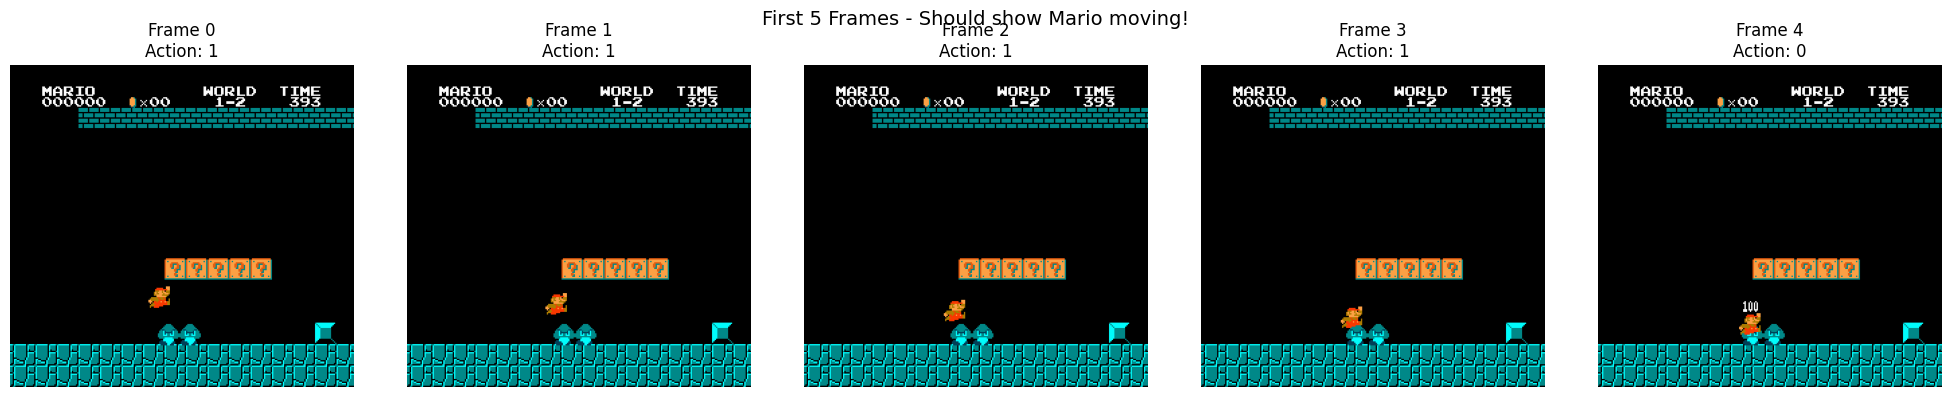


Pixel differences between consecutive frames:
  Frame 0 -> 1: 0.5505 (should be >1.0 if Mario moved)
  Frame 1 -> 2: 0.3808 (should be >1.0 if Mario moved)
  Frame 2 -> 3: 0.5472 (should be >1.0 if Mario moved)
  Frame 3 -> 4: 0.6860 (should be >1.0 if Mario moved)
  Frame 4 -> 5: 0.5872 (should be >1.0 if Mario moved)
  Frame 5 -> 6: 0.4852 (should be >1.0 if Mario moved)
  Frame 6 -> 7: 0.2877 (should be >1.0 if Mario moved)
  Frame 7 -> 8: 8.2493 (should be >1.0 if Mario moved)
  Frame 8 -> 9: 7.8835 (should be >1.0 if Mario moved)
  Frame 9 -> 10: 0.1436 (should be >1.0 if Mario moved)


In [9]:
# Visual check - plot first 5 frames side by side
import matplotlib.pyplot as plt
offset = 150
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(min(5, len(data))):
    axes[i].imshow(data[i+offset]['obs'])
    axes[i].set_title(f"Frame {i}\nAction: {data[i+offset]['action']}")
    axes[i].axis('off')
plt.suptitle("First 5 Frames - Should show Mario moving!", fontsize=14)
plt.tight_layout()
plt.show()

# Check pixel differences between consecutive frames
print("\nPixel differences between consecutive frames:")
for i in range(min(10, len(data)-1)):
    diff = np.abs(data[i+offset]['obs'].astype(float) - data[i+1+offset]['obs'].astype(float)).mean()
    print(f"  Frame {i} -> {i+1}: {diff:.4f} (should be >1.0 if Mario moved)")

In [10]:
offset = 150
# Test if environment stepping works correctly now
print("Testing if Mario environment steps correctly...")
import gym_super_mario_bros
from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT

env = gym_super_mario_bros.make('SuperMarioBros-1-1-v0')
env = JoypadSpace(env, SIMPLE_MOVEMENT)

obs1 = env.reset()
print(f"Initial obs shape: {obs1.shape}")

# Take action 1 (move right) for 10 steps
obs_list = [obs1]
for i in range(10+offset):
    obs_next, _, _, _ = env.step(1)  # Action 1 = move right (4 values for gym 0.25)
    obs_list.append(obs_next)

env.close()

# Check if observations changed
print(f"\nChecking if observations change when stepping:")
for i in range(min(5, len(obs_list)-1)):
    diff = np.abs(obs_list[i].astype(float) - obs_list[i+1].astype(float)).mean()
    same = np.array_equal(obs_list[i], obs_list[i+1])
    print(f"  Step {i} -> {i+1}: diff={diff:.2f}, identical={same}")

if all(np.array_equal(obs_list[0], obs) for obs in obs_list):
    print("\n⚠️  Environment is BROKEN - observations never change!")
else:
    print("\n✅ Environment works correctly - observations change with steps")

Testing if Mario environment steps correctly...


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/antonioricciardi/projects/scil_saps/.venv/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-1-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/home/antonioricciardi/projects/scil_saps/.venv/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/antonioricciardi/projects/scil_saps/.venv/lib/python3.9/site-package

Initial obs shape: (240, 256, 3)

Checking if observations change when stepping:
  Step 0 -> 1: diff=131.97, identical=True
  Step 1 -> 2: diff=0.00, identical=True
  Step 2 -> 3: diff=0.00, identical=True
  Step 3 -> 4: diff=0.00, identical=True
  Step 4 -> 5: diff=0.00, identical=True

⚠️  Environment is BROKEN - observations never change!


In [11]:
# Evaluate embedding quality from trained model
import torch
import torch.nn.functional as F
from models import SCILEncoder
from dataset import MarioSCILDataset
from torch.utils.data import DataLoader

# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SCILEncoder(num_actions=7, projection_dim=128).to(device)
model.load_state_dict(torch.load("scil_encoder_mario.pth"))
model.eval()

# Load some data
dataset = MarioSCILDataset("mario_*_expert.pkl", img_size=84, use_imagenet_norm=False)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

# Extract embeddings (z) and actions
all_embeddings = []
all_actions = []

with torch.no_grad():
    for obs, actions in loader:
        obs, actions = obs.to(device), actions.to(device)
        _, _, z = model(obs)
        all_embeddings.append(z.cpu())
        all_actions.append(actions.cpu())
        if len(all_embeddings) >= 10:  # Sample 1280 points
            break

embeddings = torch.cat(all_embeddings, dim=0).numpy()
actions = torch.cat(all_actions, dim=0).numpy()

print(f"Extracted {len(embeddings)} embeddings of dimension {embeddings.shape[1]}")
print(f"Actions distribution: {np.bincount(actions)}")

ModuleNotFoundError: No module named 'models'

In [ ]:
# Quantitative evaluation of embedding quality
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# 1. Silhouette Score - measures cluster quality (-1 to 1, higher is better)
silhouette = silhouette_score(embeddings, actions)
print(f"\n📊 Embedding Quality Metrics:")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   (Range: -1 to 1, >0.5 is good, >0.7 is excellent)")

# 2. Intra-class vs Inter-class distances
intra_distances = []
inter_distances = []

for action_id in range(7):
    action_mask = actions == action_id
    if action_mask.sum() < 2:
        continue
    
    action_embeddings = embeddings[action_mask]
    other_embeddings = embeddings[~action_mask]
    
    # Intra-class: average distance within same action
    if len(action_embeddings) > 1:
        intra_dist = cdist(action_embeddings, action_embeddings).mean()
        intra_distances.append(intra_dist)
    
    # Inter-class: average distance to other actions
    if len(other_embeddings) > 0:
        inter_dist = cdist(action_embeddings, other_embeddings).mean()
        inter_distances.append(inter_dist)

avg_intra = np.mean(intra_distances)
avg_inter = np.mean(inter_distances)
separation_ratio = avg_inter / avg_intra

print(f"\n   Average Intra-class Distance: {avg_intra:.4f} (smaller is better)")
print(f"   Average Inter-class Distance: {avg_inter:.4f} (larger is better)")
print(f"   Separation Ratio: {separation_ratio:.4f}")
print(f"   (Ratio > 2.0 is good, > 3.0 is excellent)")

if separation_ratio > 3.0:
    print("\n   ✅ Excellent separation! SupCon is working well.")
elif separation_ratio > 2.0:
    print("\n   ✅ Good separation! SupCon is helping.")
else:
    print("\n   ⚠️  Weak separation. SupCon could be improved.")

In [ ]:
# Visualize embeddings in 2D using t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Computing t-SNE projection (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot with colors for each action
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 7))

for action_id in range(7):
    mask = actions == action_id
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                c=[colors[action_id]], label=f'Action {action_id}',
                alpha=0.6, s=50)

plt.legend()
plt.title(f"t-SNE Visualization of Learned Embeddings (SupCon Loss: ~3.0)\n" +
          "Good SupCon → Actions form distinct clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Distinct, separated clusters → SupCon working well")
print("   - Overlapping clusters → May need more training or higher lambda")